[Home](../../README.md)

### Model Evaluation

This is a demonstration of evaluating a model.

#### Step 1

Load the required dependencies.


In [2]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pickle

####  Step 2

Load the model for testing

In [3]:
# load the exp model parameters
exp_params_file = "my_saved_poly_v3.pkl"
model_data = pickle.load(open(exp_params_file, "rb"))
a, b, c = model_data["a"], model_data["b"], model_data["c"]

def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

####  Step 3
Open and parse the test data CSV file and store the data as variable array data objects.

In [4]:
x_col = 'events_completed'
testing_data = pd.read_csv('2.4.1.testing_data.csv')
x_test = np.array(testing_data[x_col])
y_test = np.array(testing_data['average'])

#### Step 5

Plot the test data features, targets and linear regression model to visually evaluate the model.

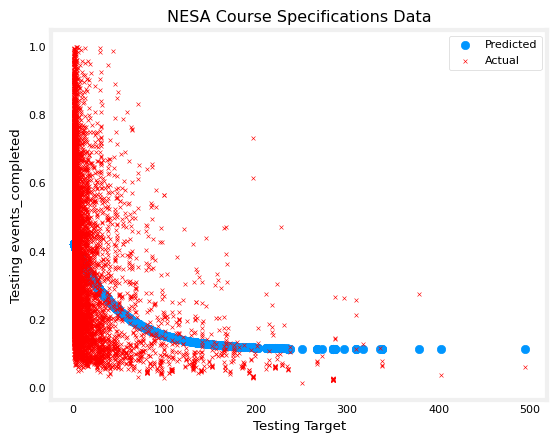

In [5]:
y_pred = exp_func(x_test, a, b, c)
plt.scatter(x_test, y_pred, label="Predicted")
plt.scatter(x_test, y_test, marker='x', c='r', s=0.1, label="Actual")
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing Target')
plt.legend()
plt.show()

#### Step 6

Use the 'score' method of the `LinearRegression` class to return a score based evaluation of the models accuracy or performance.

In [6]:
y_pred = exp_func(x_test, a, b, c)
test_score = r2_score(y_test, y_pred)
print(f"Testing data R² score: {test_score}")

Testing data R² score: 0.14011988420464283


#### Step 7

Manually calculate and evaluate the 'loss' and 'cost' of the model using the test data.

In [7]:
table = pd.DataFrame({
    testing_data.columns[0]: x_test,
    testing_data.columns[1]: y_test,
    'Predicted result':y_pred,
    'Loss' : abs(y_pred - y_test)**2
})
print(table)

cost = table["Loss"].sum() / (2 * len(table))
print(f"The cost or average loss of this model is {cost}")

      average  person_id  Predicted result      Loss
0           2   0.718471          0.416590  0.091132
1           1   0.456221          0.422819  0.001116
2           1   0.353376          0.422819  0.004822
3           2   0.314862          0.416590  0.010349
4           1   0.462972          0.422819  0.001612
...       ...        ...               ...       ...
9710       58   0.071677          0.210304  0.019217
9711        1   0.616688          0.422819  0.037585
9712        1   0.699660          0.422819  0.076641
9713        1   0.155202          0.422819  0.071619
9714        2   0.162081          0.416590  0.064775

[9715 rows x 4 columns]
The cost or average loss of this model is 0.017587844135619764


The code bellow calculates the r^2 score, mean square error, and root mean sqaured error, as well as a baseline of all calculations so they have something to compare themselves too. 

In [8]:

# my existing cost definition: J = (1 / 2m) * sum((y_pred - y_true)^2)
m = len(y_test)
J = np.sum((y_pred - y_test) ** 2) / (2 * m)

# MSE = average squared error
mse = mean_squared_error(y_test, y_pred)  # equivalent to np.mean((y_pred - y_test)**2)

# RMSE = square root of MSE 
rmse = np.sqrt(mse)

# R² = proportion of variance explained by model (higher is better, but not too)
r2 = r2_score(y_test, y_pred)

# baseline: always predict mean(y_test)
baseline_pred = np.full_like(y_test, fill_value=np.mean(y_test), dtype=float)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_pred)  # usually ~0 on test data

print("=== Model Metrics ===")
print(f"Cost J (1/2m * SSE): {J:.6f}")
print(f"MSE:                {mse:.6f}")
print(f"RMSE:               {rmse:.6f}")
print(f"R²:                 {r2:.6f}")

print("\n=== Baseline (predict mean target) ===")
print(f"Baseline MSE:       {baseline_mse:.6f}")
print(f"Baseline RMSE:      {baseline_rmse:.6f}")
print(f"Baseline R²:        {baseline_r2:.6f}")

if rmse < 0.10:
    quality = "strong"
elif rmse <= 0.20:
    quality = "moderate"
else:
    quality = "weak"

print(f"\nRMSE quality (0–1 target scale): {quality}")
print(f"Typical prediction error: ~{rmse * 100:.1f} percentage points")

=== Model Metrics ===
Cost J (1/2m * SSE): 0.017588
MSE:                0.035176
RMSE:               0.187552
R²:                 0.140120

=== Baseline (predict mean target) ===
Baseline MSE:       0.040908
Baseline RMSE:      0.202256
Baseline R²:        0.000000

RMSE quality (0–1 target scale): moderate
Typical prediction error: ~18.8 percentage points


My evauation shows the mdel is useful but only moderately accurate on this test set. The test r^2 = 0.14 means the model explains about 14 % of the variation in the target 'average', so most of the variation is unexplained. The report cost j = 0.017588 corresponds to the MSE =  0.03518 and RMSE = 0.18755, which means predictions are off by about 18.8 percentage points on average for a target scaled from 0 - 1. This falls a moderate range. Compared with the baseline (predicting only the mean target, acting as a *baseling* for the results to be compared to), the model performs better (RMSE\ 0.1876 vs 0.2023), (R^2\ 0.1401 vs approx 0), so it is learning real signal. However the improvement is very modest.

#### Step 11

When your model is ready for operations, move it to the [3.Operations\3.1.Deploy_Model](\3.Operations\3.1.Deploy_Model) folder.